In [2]:
import torch as torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(99)
np.random.seed(99)

In [10]:
device= torch.device('cuda' if(torch.cuda.is_available()) else 'cpu')
print(device)

cuda


In [1]:
def soliton(x, t, c, x0):
    arg = (torch.sqrt(torch.tensor(c)) / 2) * (x - c*t - x0)
    return (c / 2) / torch.cosh(arg)**2

In [6]:
def three_soliton(x, t):
    u = soliton(x, t, c=2.5, x0=10)  # tallest,fastest,rightmost
    u += soliton(x, t, c=2, x0=0)   # medium
    u += soliton(x, t, c=1.5, x0=-10)  # smallest,slowest,leftmost
    return u

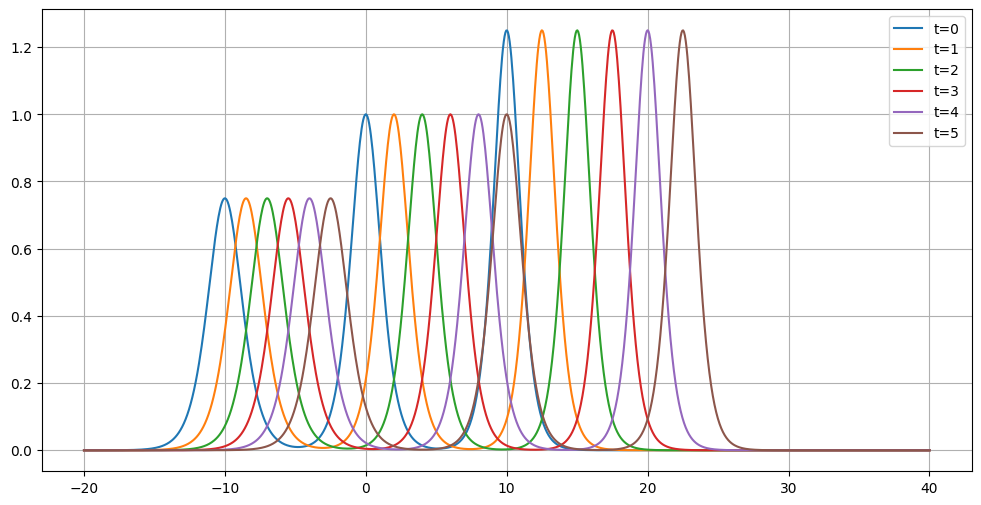

In [8]:
x = torch.linspace(-20, 40, 1000)

plt.figure(figsize=(12, 6))
for t_val in [0, 1, 2, 3, 4, 5]:
    t = torch.full_like(x, t_val)
    u = three_soliton(x, t)
    plt.plot(x.numpy(), u.numpy(), label=f't={t_val}')

plt.legend()
plt.grid(True)
plt.show()

In [12]:
#just calcs derivatives

def derivatives(model, x, t):
    u = model(x, t)

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),create_graph=True)[0]
   # btw by the underscore i mean derivative wrt what

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),create_graph=True)[0]

    u_xxx = torch.autograd.grad(u_xx, x, grad_outputs=torch.ones_like(u_xx),create_graph=True)[0]

    return u, u_t, u_x, u_xxx



In [13]:
def pde_loss(model, x, t):
    u, u_t, u_x, u_xxx = derivatives(model, x, t)
    residual = u_t + 6 * u * u_x + u_xxx   # positive convention now
    return torch.mean(residual ** 2)

In [34]:
# sets the initial condition value given t=0
def ic_loss(model, x_ic, t_ic):
    u_pred = model(x_ic, t_ic)
    u_exact = three_soliton(x_ic.squeeze(), t_ic.squeeze()).unsqueeze(1)
    return torch.mean((u_pred - u_exact) ** 2)

In [15]:
# boundary condn for x=-10 and 20
def bc_loss(model, x_bc, t_bc):
    u_pred = model(x_bc, t_bc)
    return torch.mean(u_pred ** 2)

In [16]:
def data_loss(model, x_data, t_data, u_data):
    u_pred = model(x_data, t_data)
    return torch.mean((u_pred - u_data) ** 2)

In [32]:
def total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data):
    loss_pde = pde_loss(model, x_pde, t_pde)
    loss_ic = ic_loss(model, x_ic, t_ic)
    loss_bc = bc_loss(model, x_bc, t_bc)
    loss_data = data_loss(model, x_data, t_data, u_data)
    loss = loss_pde + loss_ic + loss_bc + loss_data
    return loss, loss_pde, loss_ic, loss_bc,loss_data
#not using loss weights here since all three losses converge well with equal weights
#if ic or bc loss was stuck while pde kept dropping, we'd weight them higher to balance

In [19]:
#10000 random points across the domain to run on
n_pde = 20000
x_pde = (-20 + 60 * torch.rand(n_pde, 1)).to(device).requires_grad_(True)
t_pde = (5 * torch.rand(n_pde, 1)).to(device).requires_grad_(True)

In [25]:
# synthetic measurement data at random points across the domain
n_data = 400
x_data = (-20 + 60 * torch.rand(n_data, 1)).to(device)
t_data = (5 * torch.rand(n_data, 1)).to(device)
u_data = three_soliton(x_data.squeeze(), t_data.squeeze()).unsqueeze(1).to(device)

In [23]:
#initial condn 500 points along t=0
n_ic = 500
x_ic = torch.linspace(-20, 40, n_ic).view(-1, 1).to(device).requires_grad_(True)
t_ic = torch.zeros(n_ic, 1).to(device).requires_grad_(True)

In [24]:
#generate points at the left edge (x=−10) and right edge (x=20) for various times
n_bc = 100
t_bc_vals = torch.linspace(0, 5, n_bc).view(-1, 1).to(device)

x_bc_left = torch.full((n_bc, 1), -20.0).to(device).requires_grad_(True)
x_bc_right = torch.full((n_bc, 1), 40.0).to(device).requires_grad_(True)

x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc = torch.cat([t_bc_vals, t_bc_vals], dim=0).requires_grad_(True)

In [27]:
class PINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = torch.nn.Linear(2, 50)
        self.l2 = torch.nn.Linear(50, 50)
        self.l3 = torch.nn.Linear(50, 50)
        self.l4 = torch.nn.Linear(50, 50)
        self.l5 = torch.nn.Linear(50, 50)
        self.l6 = torch.nn.Linear(50, 50)
        self.out = torch.nn.Linear(50, 1)

        for layer in [self.l1, self.l2, self.l3, self.l4, self.l5, self.l6, self.out]:
            torch.nn.init.xavier_normal_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        inp = torch.tanh(self.l1(inp))
        inp = torch.tanh(self.l2(inp))
        inp = torch.tanh(self.l3(inp))
        inp = torch.tanh(self.l4(inp))
        inp = torch.tanh(self.l5(inp))
        inp = torch.tanh(self.l6(inp))
        return self.out(inp)

In [28]:
model = PINN().to(device)
x_test = torch.rand(5, 1).to(device)
t_test = torch.rand(5, 1).to(device)
print(model(x_test, t_test))

tensor([[ 0.0590],
        [ 0.0641],
        [ 0.0478],
        [ 0.0242],
        [-0.0248]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [35]:
#run 15,000 iterations where the network adjusts its weights to minimize the total loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
pde_losses = []
ic_losses = []
bc_losses = []
data_losses=[]
for i in range(15000):
    optimizer.zero_grad()

    loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data)


    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    pde_losses.append(l_pde.item())
    ic_losses.append(l_ic.item())
    bc_losses.append(l_bc.item())
    data_losses.append(l_data.item())

    if i % 500 == 0:
        print(f"Iter {i:5d} | Total: {loss.item():.6f} | PDE: {l_pde.item():.6f} | IC: {l_ic.item():.6f} | BC: {l_bc.item():.6f} | dataloss: {l_data.item():.6f}")
#

Iter     0 | Total: 0.657664 | PDE: 0.006143 | IC: 0.235444 | BC: 0.184557 | dataloss: 0.231520
Iter   500 | Total: 0.002412 | PDE: 0.001063 | IC: 0.000269 | BC: 0.000005 | dataloss: 0.001074
Iter  1000 | Total: 0.000231 | PDE: 0.000134 | IC: 0.000021 | BC: 0.000000 | dataloss: 0.000075
Iter  1500 | Total: 0.000158 | PDE: 0.000073 | IC: 0.000031 | BC: 0.000023 | dataloss: 0.000030
Iter  2000 | Total: 0.000051 | PDE: 0.000032 | IC: 0.000007 | BC: 0.000001 | dataloss: 0.000011
Iter  2500 | Total: 0.000617 | PDE: 0.000087 | IC: 0.000210 | BC: 0.000038 | dataloss: 0.000281
Iter  3000 | Total: 0.000031 | PDE: 0.000018 | IC: 0.000004 | BC: 0.000004 | dataloss: 0.000006
Iter  3500 | Total: 0.000054 | PDE: 0.000018 | IC: 0.000016 | BC: 0.000000 | dataloss: 0.000019
Iter  4000 | Total: 0.000276 | PDE: 0.000071 | IC: 0.000100 | BC: 0.000006 | dataloss: 0.000099
Iter  4500 | Total: 0.000411 | PDE: 0.000109 | IC: 0.000145 | BC: 0.000029 | dataloss: 0.000128
Iter  5000 | Total: 0.000121 | PDE: 0.00

In [39]:
x_test = torch.linspace(-10, 20, 200)
t_test = torch.linspace(0, 5, 100)

X, T = torch.meshgrid(x_test, t_test, indexing='ij')
x_flat = X.reshape(-1, 1).to(device)
t_flat = T.reshape(-1, 1).to(device)

with torch.no_grad():
    u_pred = model(x_flat, t_flat).cpu().numpy().reshape(200, 100)

u_exact = three_soliton(X.reshape(-1), T.reshape(-1)).numpy().reshape(200, 100)
l2_error = np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2))
print(f"L2 Relative Error: {l2_error * 100:.4f}%")

L2 Relative Error: 2.3056%


In [40]:
opt2 = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50)

for i in range(2000):
    def closure():
        opt2.zero_grad()
        loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data)
        loss.backward()
        return loss

    opt2.step(closure)

    if i % 100 == 0:
        loss, l_pde, l_ic, l_bc, l_data = total_loss(model, x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_data, t_data, u_data)
        print(f"LBFGS {i} | Total: {loss.item():.10f}")

LBFGS 0 | Total: 0.0000371426
LBFGS 100 | Total: 0.0000013866
LBFGS 200 | Total: 0.0000013866
LBFGS 300 | Total: 0.0000013866
LBFGS 400 | Total: 0.0000013866
LBFGS 500 | Total: 0.0000013866
LBFGS 600 | Total: 0.0000013866
LBFGS 700 | Total: 0.0000013866
LBFGS 800 | Total: 0.0000013866
LBFGS 900 | Total: 0.0000013866
LBFGS 1000 | Total: 0.0000013866
LBFGS 1100 | Total: 0.0000013866
LBFGS 1200 | Total: 0.0000013866
LBFGS 1300 | Total: 0.0000013866
LBFGS 1400 | Total: 0.0000013866
LBFGS 1500 | Total: 0.0000013866
LBFGS 1600 | Total: 0.0000013866
LBFGS 1700 | Total: 0.0000013866
LBFGS 1800 | Total: 0.0000013866
LBFGS 1900 | Total: 0.0000013866


In [45]:
with torch.no_grad():
    u_pred = model(x_flat, t_flat).cpu().numpy().reshape(200, 100)

u_exact = three_soliton(X.reshape(-1), T.reshape(-1)).numpy().reshape(200, 100)

l2_error = np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2))
print(f"L2 Relative Error: {l2_error * 100:.4f}%")

L2 Relative Error: 0.1466%


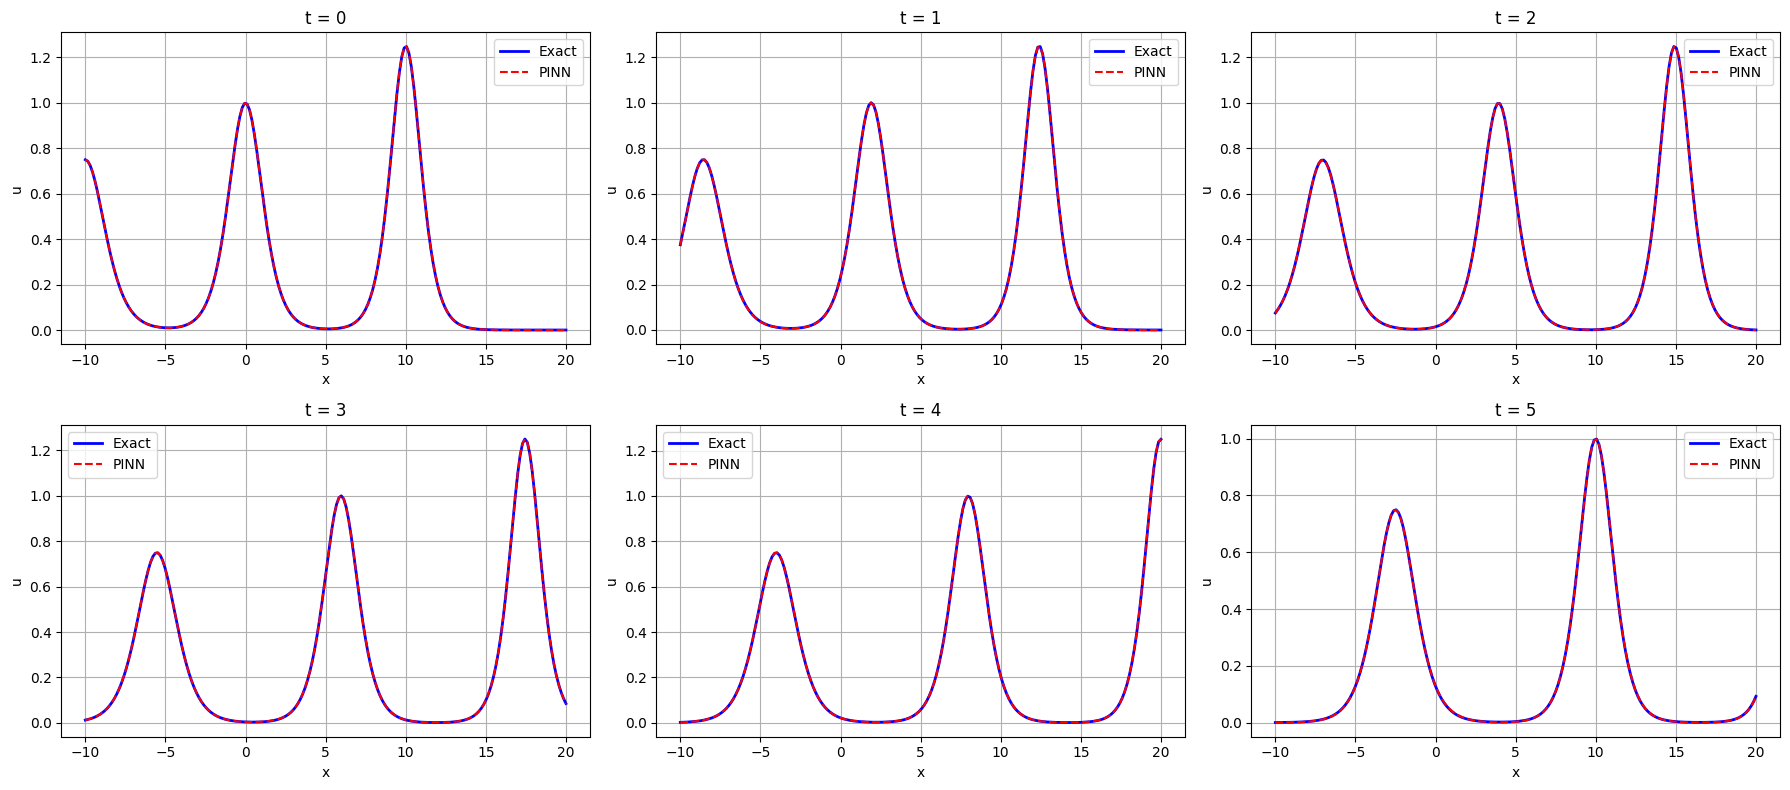

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
times = [0, 1, 2, 3, 4, 5]

for idx, t_val in enumerate(times):
    ax = axes[idx // 3][idx % 3]
    t_idx = int(t_val * 99 / 5)
    ax.plot(x_test.numpy(), u_exact[:, t_idx], 'b-', label='Exact', linewidth=2)
    ax.plot(x_test.numpy(), u_pred[:, t_idx], 'r--', label='PINN', linewidth=1.5)
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

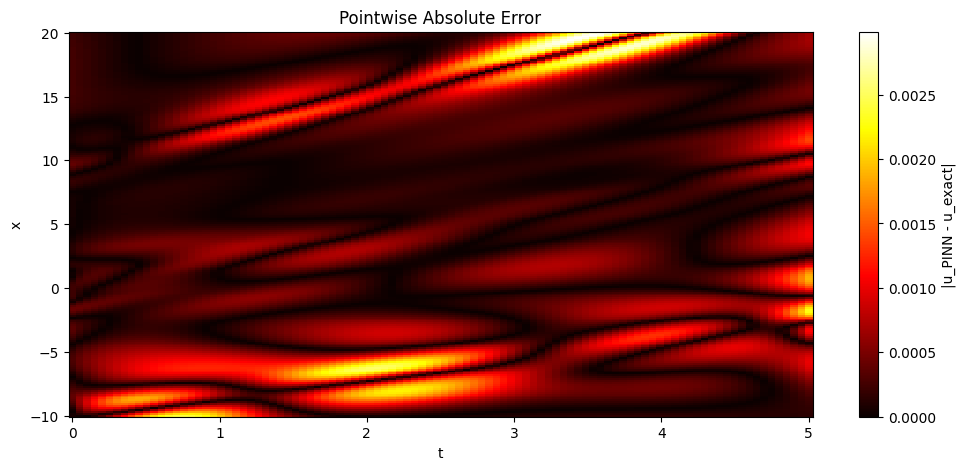

In [44]:
error = np.abs(u_pred - u_exact)
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_test.numpy(), x_test.numpy(), error, cmap='hot')
plt.colorbar(label='|u_PINN - u_exact|')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Pointwise Absolute Error')
plt.show()